## 1. Configuración Inicial y Carga de Datos

En esta sección se prepara el entorno de trabajo: se monta Google Drive para acceder a los datasets, se importan todas las librerías necesarias y se cargan los archivos que componen el ecosistema de datos para el Mundial 2026.

### Archivos disponibles

- **datos_historicos.csv**: Historial de partidos internacionales con estadísticas detalladas (medias móviles, xG, posesión, etc.). Es la base para entrenar el modelo de red neuronal.
- **datos_mundial.csv**: Perfil de cada selección participante en el Mundial, con sus medias estadísticas actualizadas (una fila por equipo).
- **Grupos_Mundial.csv**: Composición de los 12 grupos del Mundial (equipo y grupo asignado).
- **partidos_mundial.csv**: Calendario de la fase de grupos (48 partidos) con columnas para estadísticas (vacías inicialmente).
- **ranking_fifa.csv**: Puntuación FIFA de cada selección (actualizada).
- **transfermarkt.csv**: Valor de mercado (en millones de euros) de cada selección.

### Procesamiento inicial

- Se cargan todos los archivos.
- Se corrige el formato de `Grupos_Mundial.csv` (que viene con una columna combinada 'Equipo;Grupo').
- Se verifica que todos los equipos de los grupos estén presentes en `datos_mundial.csv`.
- Se preparan los datos para las siguientes etapas de feature engineering y modelado.

In [ ]:
# ====================================================================
# PASO 1: CONFIGURACIÓN INICIAL Y CARGA DE DATOS
# ====================================================================

# 1.1 Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 1.2 Definir ruta base
base_path = '/content/drive/MyDrive/Simulaciones_Mundial/Data'  # Ajusta según tu estructura

# 1.3 Importar librerías necesarias
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# 1.4 Listar archivos disponibles en la ruta
print("📂 Archivos disponibles en la ruta:")
for f in os.listdir(base_path):
    print(f"  - {f}")

# ====================================================================
# 1.5 Cargar todos los datasets
# ====================================================================

# 1.5.1 Datos históricos (entrenamiento)
df_historicos = pd.read_csv(f'{base_path}/datos_historicos.csv')
print("\n📊 datos_historicos.csv:")
print(f"  Shape: {df_historicos.shape}")
print(f"  Columnas (primeras 10): {df_historicos.columns.tolist()[:10]}")

# 1.5.2 Perfil de equipos para el Mundial
df_mundial_vars = pd.read_csv(f'{base_path}/datos_mundial.csv')
print("\n📊 datos_mundial.csv:")
print(f"  Shape: {df_mundial_vars.shape}")
print(f"  Columnas (primeras 10): {df_mundial_vars.columns.tolist()[:10]}")
print(f"  Equipos (primeros 10): {df_mundial_vars['Equipo'].unique()[:10]}")

# 1.5.3 Grupos del Mundial
df_grupos = pd.read_csv(f'{base_path}/Grupos_Mundial.csv')
print("\n📊 Grupos_Mundial.csv:")
print(f"  Shape: {df_grupos.shape}")
print(f"  Columnas: {df_grupos.columns.tolist()}")
print(df_grupos.head())

# 1.5.4 Partidos del Mundial (calendario)
df_partidos_mundial = pd.read_csv(f'{base_path}/partidos_mundial.csv')
print("\n📊 partidos_mundial.csv:")
print(f"  Shape: {df_partidos_mundial.shape}")
print(f"  Columnas: {df_partidos_mundial.columns.tolist()[:10]}")
print(df_partidos_mundial.head())

# 1.5.5 Ranking FIFA
df_ranking = pd.read_csv(f'{base_path}/ranking_fifa.csv')
print("\n📊 ranking_fifa.csv:")
print(f"  Shape: {df_ranking.shape}")
print(f"  Columnas: {df_ranking.columns.tolist()}")
print(df_ranking.head())

# 1.5.6 Transfermarkt (valor de mercado)
df_transfer = pd.read_csv(f'{base_path}/transfermarkt.csv')
print("\n📊 transfermarkt.csv:")
print(f"  Shape: {df_transfer.shape}")
print(f"  Columnas: {df_transfer.columns.tolist()}")
print(df_transfer.head())

# ====================================================================
# 1.6 Limpieza y corrección de formatos
# ====================================================================

# 1.6.1 Corregir formato de Grupos_Mundial.csv
if 'Equipo;Grupo' in df_grupos.columns:
    print("\n⚠️ Detectado formato 'Equipo;Grupo'. Separando columnas...")
    split_data = df_grupos['Equipo;Grupo'].str.split(';', expand=True)
    df_grupos['Equipo'] = split_data[0]
    df_grupos['Grupo'] = split_data[1]
    df_grupos = df_grupos.drop(columns=['Equipo;Grupo'])
    print("✅ Columnas 'Equipo' y 'Grupo' creadas.")

# 1.6.2 Verificar que todos los equipos de grupos estén en datos_mundial
equipos_grupos = set(df_grupos['Equipo'].unique())
equipos_mundial = set(df_mundial_vars['Equipo'].unique())
faltan = equipos_grupos - equipos_mundial
if faltan:
    print(f"\n⚠️ Equipos en grupos pero no en datos_mundial: {faltan}")
else:
    print("\n✅ Todos los equipos de los grupos están en datos_mundial.csv")

# 1.6.3 Verificar que los equipos de partidos_mundial estén en datos_mundial
equipos_partidos = set(df_partidos_mundial['Equipo_Local']).union(set(df_partidos_mundial['Equipo_Visitante']))
faltan_partidos = equipos_partidos - equipos_mundial
if faltan_partidos:
    print(f"⚠️ Equipos en partidos pero no en datos_mundial: {faltan_partidos}")
else:
    print("✅ Todos los equipos de los partidos están en datos_mundial.csv")

# 1.6.4 Mostrar resumen de equipos por grupo
print("\n📋 Equipos por grupo:")
for grupo in sorted(df_grupos['Grupo'].unique()):
    equipos = df_grupos[df_grupos['Grupo'] == grupo]['Equipo'].tolist()
    print(f"  Grupo {grupo}: {', '.join(equipos)}")

print("\n✅ PASO 1 COMPLETADO: Datos cargados y verificados.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 Archivos disponibles en la ruta:
  - Grupos_Mundial.csv
  - partidos.csv
  - ranking_fifa.csv
  - urls.txt
  - transfermarkt.csv
  - datos_historicos.csv
  - datos_mundial.csv
  - partidos_mundial.csv

📊 datos_historicos.csv:
  Shape: (1396, 48)
  Columnas (primeras 10): ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Goles_Local', 'Goles_Visitante', 'Peso_Local', 'avg_Goles_esperados_(xG)_total_Local', 'avg_Tarjetas_amarillas_total_Local', 'avg_Faltas_total_Local', 'avg_Remates_a_puerta_3_Local']

📊 datos_mundial.csv:
  Shape: (48, 47)
  Columnas (primeras 10): ['Equipo', 'Puntos', 'Peso', 'Valor_Mercado_Millones_Eur', 'Tipo_Equipo', 'Fecha', 'Resultado_1X2', 'avg_Goles_esperados_(xG)_total', 'avg_Posesión_total', 'avg_Remates_a_puerta_total']
  Equipos (primeros 10): ['Sudáfrica' 'México' 'República Checa' 'Corea del Sur' 'Canadá'
 'Bosnia-Herzegovina' 'Pa

## PASO 2: PREPARACIÓN DE DATOS PARA ENTRENAMIENTO (Implementación activa en la celda `o31CObcB-TiA`)

Esta celda ha sido reemplazada por la implementación más completa y activa del 'Paso 2' que incluye One-Hot Encoding y otras verificaciones. Por favor, consulte la celda de código `o31CObcB-TiA` para el procesamiento de datos del 'Paso 2'.

## 2. Ingeniería de Variables y Preparación del Modelo

En esta sección, preparamos los datos históricos para el entrenamiento de la red neuronal. Replicamos las 45 variables del notebook original y las estructuramos correctamente para el modelo de Deep Learning.

### 2.1. Limpieza y Codificación de la Variable Objetivo

Primero, eliminamos filas con valores nulos (principalmente el primer partido de cada selección donde las medias móviles no tienen historia) y codificamos la variable objetivo `Resultado_1X2` en formato numérico para la clasificación multiclase:

- `1` → Victoria Local → clase `0`
- `X` → Empate → clase `1`
- `2` → Victoria Visitante → clase `2`

### 2.2. Matriz de Covariables ($\mathbf{X}$)

Eliminamos las columnas no predictivas (`Fecha`, `Equipo_Local`, `Equipo_Visitante`, los goles reales y el resultado textual) para construir la matriz de entrada `X` con las 45 variables predictoras. Esta será la entrada de nuestra red neuronal.

### 2.3. División Temporal (Train/Test)

Para respetar la causalidad temporal, dividimos los datos en 85% entrenamiento y 15% prueba, manteniendo el orden cronológico. Esta división es crucial para evaluar correctamente el rendimiento del modelo en datos futuros.

### 2.4. Guardado de Columnas

Guardamos la lista de nombres de columnas en el orden exacto en que están en `X`. Esto será esencial más adelante cuando construyamos los vectores de características para los partidos del Mundial, asegurando que las columnas estén en el mismo orden y así el modelo pueda hacer predicciones correctamente.

### 2.5. Codificación One-Hot para la Red Neuronal

A diferencia de XGBoost (que puede trabajar con etiquetas enteras), las redes neuronales con `softmax` requieren que las etiquetas estén en formato one-hot encoding. Convertimos `y_train` e `y_test` a este formato.

### 2.6. Verificación Final

Comprobamos que no haya valores nulos en `X` y que las dimensiones sean consistentes.

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler # Import StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

print("=== INGENIERÍA DE VARIABLES Y PREPARACIÓN DEL MODELO ===\n")

# ----------------------------------------------------------------
# 2.1. Limpieza y Codificación de la Variable Objetivo
# ----------------------------------------------------------------

# Mapeo de resultados: '1' -> 0 (Local), 'X' -> 1 (Empate), '2' -> 2 (Visitante)
mapeo_resultados = {
    '1': 0,  # Victoria Local
    'X': 1,  # Empate
    '2': 2   # Victoria Visitante
}

# Crear la variable objetivo numérica en una copia para procesamiento
df_historicos_processed = df_historicos.copy()
df_historicos_processed['Resultado_1X2_Num'] = df_historicos_processed['Resultado_1X2'].map(mapeo_resultados)

# Identificar columnas numéricas para imputación (excluyendo el objetivo y las columnas de resultado directo)
numeric_cols_to_impute = [
    col for col in df_historicos_processed.columns
    if df_historicos_processed[col].dtype in ['float64', 'int64'] and
       not col.startswith('Goles_') and # Excluir Goles_Local/Visitante
       col not in ['Resultado_1X2_Num'] # Excluir el objetivo
]

# Imputar NaNs en estas columnas numéricas con su media
for col in numeric_cols_to_impute:
    if df_historicos_processed[col].isnull().any():
        mean_val = df_historicos_processed[col].mean()
        df_historicos_processed[col] = df_historicos_processed[col].fillna(mean_val)
        print(f"  Imputed NaNs in '{col}' with mean: {mean_val:.2f}")

# Ahora, eliminamos filas donde la variable objetivo pudiera ser NaN (aunque no debería si el mapeo es completo)
df_historicos_clean = df_historicos_processed.dropna(subset=['Resultado_1X2_Num'])
print(f"Filas después de imputar y limpiar el objetivo: {df_historicos_clean.shape[0]}")

# Definir X e y
y = df_historicos_clean['Resultado_1X2_Num']

print(f"Distribución de clases en y:")
print(y.value_counts(normalize=True).round(3))

# ----------------------------------------------------------------
# 2.2. Matriz de Covariables (X)
# ----------------------------------------------------------------

# Eliminar columnas no predictivas y redundantes/problemáticas
columnas_a_eliminar = [
    'Fecha',
    'Equipo_Local',
    'Equipo_Visitante',
    'Resultado_1X2',
    'Resultado_1X2_Num',
    'Goles_Local',
    'Goles_Visitante',
    'Prob_Implicita_ELO', # Eliminada por problemas de derivación y redundancia
    'diff_Tier'           # Eliminada por alta correlación con diff_Puntos
]

X = df_historicos_clean.drop(columns=columnas_a_eliminar, errors='ignore')
print(f"\nNúmero de variables predictoras (features): {X.shape[1]}")
print(f"Primeras 5 columnas: {list(X.columns[:5])}")

# Verificar que no haya nulos residuales
assert X.isnull().sum().sum() == 0, "❌ Aún hay valores nulos en X"

# ----------------------------------------------------------------
# 2.3. División Temporal (Train/Test)
# ----------------------------------------------------------------

# Índice de corte: 85% para entrenamiento, 15% para prueba
split_index = int(len(X) * 0.85)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"\nDivisión temporal:")
print(f"  Entrenamiento: {X_train.shape[0]} partidos ({split_index/len(X)*100:.1f}%)")
print(f"  Prueba: {X_test.shape[0]} partidos ({(len(X)-split_index)/len(X)*100:.1f}%)")

# ----------------------------------------------------------------
# 2.4. Escalado de características (StandardScaler)
# ----------------------------------------------------------------
print("\n🚀 Escalando características con StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir de nuevo a DataFrame para mantener los nombres de las columnas
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

joblib.dump(scaler, 'scaler.pkl')
print("✅ StandardScaler guardado como 'scaler.pkl'")

# ----------------------------------------------------------------
# 2.5. Guardado de Columnas (para el pipeline de predicción)
# ----------------------------------------------------------------

columnas_entrenamiento = list(X.columns)
joblib.dump(columnas_entrenamiento, 'columnas_entrenamiento.pkl')
print(f"\n✅ Columnas guardadas en 'columnas_entrenamiento.pkl'")
print(f"Total de columnas: {len(columnas_entrenamiento)}")

# ----------------------------------------------------------------
# 2.6. Codificación One-Hot para la Red Neuronal
# ----------------------------------------------------------------

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print(f"\nOne-hot encoding completado:")
print(f"  y_train_cat shape: {y_train_cat.shape}")
print(f"  y_test_cat shape: {y_test_cat.shape}")
print(f"  Ejemplo de una fila one-hot: {y_train_cat[0]}")

# ----------------------------------------------------------------
# 2.7. Calcular Class Weights para manejar el desbalance
# ----------------------------------------------------------------
classes = np.unique(y_train)
class_weights_array = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {i: class_weights_array[i] for i in classes}
print(f"\nClass Weights calculados: {class_weights}")

# ----------------------------------------------------------------
# 2.8. Verificación Final
# ----------------------------------------------------------------

print("\n=== VERIFICACIÓN FINAL ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Columnas en X: {len(columnas_entrenamiento)}")

# Mostrar un resumen de las primeras filas de X_train (escalado)
print("\nPrimeras 3 filas de X_train (escalado, ejemplo):")
print(X_train.head(3).round(2))


=== INGENIERÍA DE VARIABLES Y PREPARACIÓN DEL MODELO ===

  Imputed NaNs in 'Peso_Local' with mean: 0.84
  Imputed NaNs in 'avg_Goles_esperados_(xG)_total_Local' with mean: 1.41
  Imputed NaNs in 'avg_Tarjetas_amarillas_total_Local' with mean: 1.87
  Imputed NaNs in 'avg_Faltas_total_Local' with mean: 11.88
  Imputed NaNs in 'avg_Remates_a_puerta_3_Local' with mean: 4.23
  Imputed NaNs in 'avg_Córneres_3_Local' with mean: 4.57
  Imputed NaNs in 'avg_Tarjetas_amarillas_3_Local' with mean: 1.90
  Imputed NaNs in 'avg_Faltas_3_Local' with mean: 11.94
  Imputed NaNs in 'avg_Paradas_3_Local' with mean: 2.72
  Imputed NaNs in 'avg_Pases_Pct_3_Local' with mean: 0.79
  Imputed NaNs in 'avg_Pases_Exitosos_3_Local' with mean: 370.92
  Imputed NaNs in 'Peso_Visitante' with mean: 0.84
  Imputed NaNs in 'avg_Goles_esperados_(xG)_total_Visitante' with mean: 1.37
  Imputed NaNs in 'avg_Tarjetas_amarillas_total_Visitante' with mean: 1.90
  Imputed NaNs in 'avg_Faltas_total_Visitante' with mean: 11.93


## 2. Ingeniería de Variables y Preparación del Modelo (Descripción Completa en la Celda Anterior)

Esta sección contiene la descripción detallada del 'Paso 2: Ingeniería de Variables y Preparación del Modelo', que se encuentra en la celda de texto `sh002neq-C5G` justo encima de la implementación de código activa (`o31CObcB-TiA`).

In [ ]:
# ====================================================================
# 2.1 MAPEO DE CONTINENTES Y PESOS GEOGRÁFICOS
# ====================================================================

# Mapa de continentes (basado en el notebook original, ampliado con más equipos)
mapa_continentes = {
    # EUROPA (UEFA)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa', 'Ucrania': 'Europa', 'Polonia': 'Europa',
    'Serbia': 'Europa', 'Dinamarca': 'Europa', 'Italia': 'Europa',
    'Gales': 'Europa', 'Rusia': 'Europa', 'Macedonia del Norte': 'Europa',
    'Irlanda': 'Europa', 'Andorra': 'Europa', 'Chipre': 'Europa',
    'Islandia': 'Europa', 'Eslovaquia': 'Europa', 'Eslovenia': 'Europa',
    'Hungría': 'Europa', 'Rumanía': 'Europa', 'Bulgaria': 'Europa',
    'Grecia': 'Europa', 'Albania': 'Europa', 'Montenegro': 'Europa',
    'Kosovo': 'Europa', 'Finlandia': 'Europa', 'Bielorrusia': 'Europa',
    'Georgia': 'Europa', 'Armenia': 'Europa', 'Azerbaiyán': 'Europa',
    'Letonia': 'Europa', 'Lituania': 'Europa', 'Estonia': 'Europa',
    'Moldavia': 'Europa', 'Luxemburgo': 'Europa', 'Malta': 'Europa',
    'Liechtenstein': 'Europa', 'San Marino': 'Europa', 'Gibraltar': 'Europa',

    # SUDAMÉRICA (CONMEBOL)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    'Chile': 'Sudamérica', 'Perú': 'Sudamérica', 'Venezuela': 'Sudamérica',
    'Bolivia': 'Sudamérica',

    # NORTEAMÉRICA Y CARIBE (CONCACAF)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    'Costa Rica': 'Norteamérica', 'Honduras': 'Norteamérica', 'El Salvador': 'Norteamérica',
    'Trinidad y Tobago': 'Norteamérica', 'Jamaica': 'Norteamérica', 'Nicaragua': 'Norteamérica',

    # ÁFRICA (CAF)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa', 'Camerún': 'Africa', 'Zambia': 'Africa',
    'Nigeria': 'Africa', 'Mali': 'Africa', 'Burkina Faso': 'Africa',
    'Guinea': 'Africa', 'Benín': 'Africa', 'Togo': 'Africa',
    'Libia': 'Africa', 'Sudán': 'Africa',

    # ASIA (AFC)
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia', 'Tailandia': 'Asia', 'China': 'Asia',
    'Siria': 'Asia', 'Líbano': 'Asia', 'Emiratos Árabes Unidos': 'Asia',
    'Omán': 'Asia', 'Baréin': 'Asia', 'Kuwait': 'Asia',
    'Vietnam': 'Asia', 'India': 'Asia',
}

# Pesos por continente (factor de ajuste para sede neutral)
pesos_continente = {
    'Europa': 1.00,
    'Sudamérica': 0.95,
    'Norteamérica': 0.75,
    'Africa': 0.60,
    'Asia': 0.70,
    'Oceanía': 0.50,
}

def asignar_peso_continente(equipo):
    """Devuelve el peso geográfico de un equipo según su confederación."""
    continente = mapa_continentes.get(equipo, 'Europa')  # Por defecto Europa
    return pesos_continente.get(continente, 1.0)

# Probar con algunos equipos
print("Prueba de asignación de pesos:")
for equipo in ['Argentina', 'Francia', 'México', 'Senegal', 'Japón', 'Nueva Zelanda']:
    print(f"  {equipo}: {asignar_peso_continente(equipo)}")

Prueba de asignación de pesos:
  Argentina: 0.95
  Francia: 1.0
  México: 0.75
  Senegal: 0.6
  Japón: 0.7
  Nueva Zelanda: 0.7


In [ ]:
# ====================================================================
# 2.2 FUNCIÓN PARA ASIGNAR TIER (NIVEL)
# ====================================================================

def asignar_tier(puntos):
    """
    Asigna un nivel (tier) basado en los puntos FIFA.
    1 = Élite (puntos >= 1700)
    2 = Alto (1600-1699)
    3 = Medio (1500-1599)
    4 = Bajo (< 1500)
    """
    if puntos >= 1700:
        return 1
    elif puntos >= 1600:
        return 2
    elif puntos >= 1500:
        return 3
    else:
        return 4

# Prueba
print("Prueba de asignación de tier:")
for pts in [1750, 1650, 1550, 1400]:
    print(f"  {pts} -> Tier {asignar_tier(pts)}")

Prueba de asignación de tier:
  1750 -> Tier 1
  1650 -> Tier 2
  1550 -> Tier 3
  1400 -> Tier 4


In [ ]:
# ====================================================================
# 2.3 FEATURE ENGINEERING EN DATOS HISTÓRICOS
# ====================================================================

print("🔧 Aplicando feature engineering a datos_historicos...")

# Crear una copia del dataset histórico para no modificar el original
df_hist_clean = df_historicos.copy()

# 1. Eliminar filas con nulos (ya se hizo al cargar, pero lo reforzamos)
df_hist_clean.dropna(inplace=True)
print(f"  Filas después de eliminar nulos: {df_hist_clean.shape[0]}")

# 2. Verificar que las columnas 'Peso_Local' y 'Peso_Visitante' existen
#    Si no existen, las creamos usando el mapa de continentes
if 'Peso_Local' not in df_hist_clean.columns:
    print("  Creando columna Peso_Local...")
    df_hist_clean['Peso_Local'] = df_hist_clean['Equipo_Local'].apply(asignar_peso_continente)
if 'Peso_Visitante' not in df_hist_clean.columns:
    print("  Creando columna Peso_Visitante...")
    df_hist_clean['Peso_Visitante'] = df_hist_clean['Equipo_Visitante'].apply(asignar_peso_continente)

# 3. Verificar que las columnas 'diff_Puntos', 'Prob_Implicita_ELO', 'diff_Tier', 'diff_Valor_Mercado' existen
#    Si no existen, las creamos (suponiendo que los datos originales ya las tienen)
if 'diff_Puntos' not in df_hist_clean.columns:
    print("  Creando diff_Puntos... (debes tener los puntos FIFA en 'Puntos_Local' y 'Puntos_Visitante')")
    # Aquí asumimos que el dataset original ya tiene estas columnas.
    # Si no, habría que hacer un merge con ranking_fifa.csv.

# 4. Verificar que no haya columnas con nombres extraños
#    (El dataset original ya tiene las 45 columnas, solo verificamos)

print("  Columnas disponibles en df_hist_clean:")
print(f"    {df_hist_clean.columns.tolist()[:5]} ... {df_hist_clean.columns.tolist()[-5:]}")

# 5. Separar X (características) y y (variable objetivo)
columnas_a_eliminar = ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Resultado_1X2', 'Resultado_1X2_Num', 'Goles_Local', 'Goles_Visitante']
X = df_hist_clean.drop(columns=columnas_a_eliminar, errors='ignore')
y = df_hist_clean['Resultado_1X2_Num'] if 'Resultado_1X2_Num' in df_hist_clean.columns else df_hist_clean['Resultado_1X2']

print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")

# Guardar la lista de columnas en el orden exacto
columnas_entrenamiento = list(X.columns)
joblib.dump(columnas_entrenamiento, 'columnas_entrenamiento.pkl')
print(f"  Columnas guardadas en 'columnas_entrenamiento.pkl'")

🔧 Aplicando feature engineering a datos_historicos...
  Filas después de eliminar nulos: 153
  Columnas disponibles en df_hist_clean:
    ['Fecha', 'Equipo_Local', 'Equipo_Visitante', 'Goles_Local', 'Goles_Visitante'] ... ['diff_avg_Pases_Exitosos_3', 'diff_Puntos', 'Prob_Implicita_ELO', 'diff_Tier', 'diff_Valor_Mercado']
  X shape: (153, 42)
  y shape: (153,)
  Columnas guardadas en 'columnas_entrenamiento.pkl'


In [ ]:
# ====================================================================
# 2.4 DIVISIÓN TEMPORAL (Train/Test)
# ====================================================================

from sklearn.model_selection import TimeSeriesSplit

# División temporal: 85% para entrenamiento, 15% para prueba
split_index = int(len(df_hist_clean) * 0.85)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"📊 División temporal:")
print(f"  Entrenamiento: {X_train.shape[0]} partidos ({split_index/len(df_hist_clean)*100:.1f}%)")
print(f"  Prueba: {X_test.shape[0]} partidos ({ (len(df_hist_clean)-split_index)/len(df_hist_clean)*100:.1f}%)")

# Verificar distribución de clases
print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True).round(3))

📊 División temporal:
  Entrenamiento: 130 partidos (85.0%)
  Prueba: 23 partidos (15.0%)

Distribución de clases en entrenamiento:
Resultado_1X2
1    0.362
X    0.323
2    0.315
Name: proportion, dtype: float64

Distribución de clases en prueba:
Resultado_1X2
X    0.435
2    0.348
1    0.217
Name: proportion, dtype: float64


✅ Utilizando datos ya preparados del Paso 2:
  Entrenamiento: 1186 partidos
  Prueba: 210 partidos
  Características: 40

🚀 Entrenando el modelo de red neuronal...
Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.3592 - loss: 1.5592 - val_accuracy: 0.4667 - val_loss: 1.0271 - learning_rate: 5.0000e-04
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3769 - loss: 1.3755 - val_accuracy: 0.5476 - val_loss: 0.9762 - learning_rate: 5.0000e-04
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4292 - loss: 1.2854 - val_accuracy: 0.5619 - val_loss: 0.9415 - learning_rate: 5.0000e-04
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4309 - loss: 1.2993 - val_accuracy: 0.5857 - val_loss: 0.9146 - learning_rate: 5.0000e-04
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4570 - loss: 1.2154 - val_accuracy: 0.5952 - val_loss: 0.8997 - learning_rate: 5.0000e-04
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - ac

✅ Entrenamiento completado.
✅ Modelo guardado como 'modelo_1X2_red_neuronal.h5'
✅ Columnas de entrenamiento guardadas (40 columnas)

📊 Evaluación en el conjunto de prueba:

🌡️ Calibrando temperatura...
✅ Temperatura óptima encontrada: 0.248
✅ Temperatura óptima guardada como 'optimal_temperature.pkl'
✅ Accuracy (calibrado): 0.6143

📋 Reporte de clasificación (calibrado):
               precision    recall  f1-score   support

    Local (1)       0.73      0.74      0.73        91
   Empate (X)       0.37      0.32      0.34        56
Visitante (2)       0.64      0.70      0.67        63

     accuracy                           0.61       210
    macro avg       0.58      0.59      0.58       210
 weighted avg       0.60      0.61      0.61       210



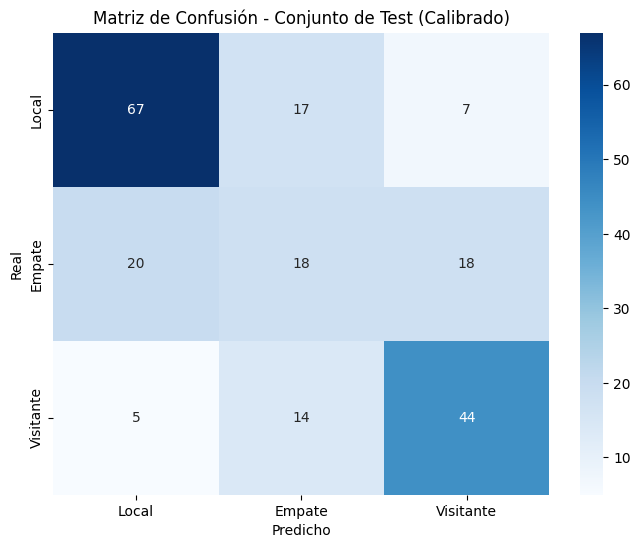

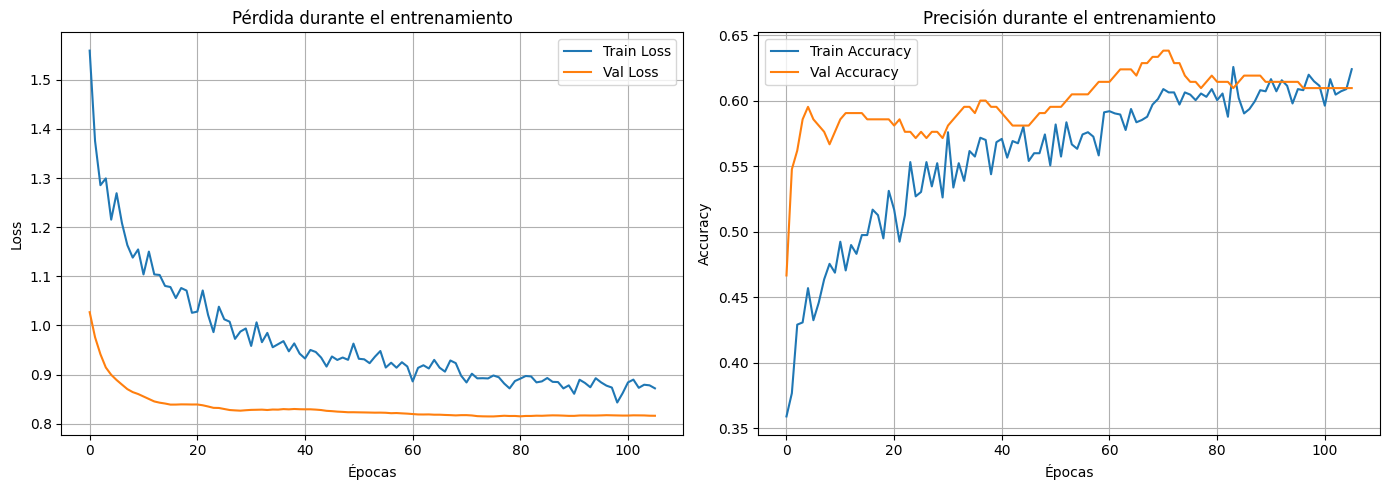


🚀 Reentrenando con el 100% de los datos (modelo de producción)...
Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3701 - loss: 1.6115 - val_accuracy: 0.4750 - val_loss: 1.6339 - learning_rate: 5.0000e-04
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4167 - loss: 1.4227 - val_accuracy: 0.4964 - val_loss: 1.1542 - learning_rate: 5.0000e-04
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4525 - loss: 1.2893 - val_accuracy: 0.5214 - val_loss: 0.9733 - learning_rate: 5.0000e-04
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4857 - loss: 1.2177 - val_accuracy: 0.5571 - val_loss: 0.8848 - learning_rate: 5.0000e-04
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4928 - loss: 1.2046 - val_accuracy: 0.5857 - val_loss: 0.8436 - learning_rate: 5.0000e-04
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4812 - loss: 1.2036 - val_accuracy: 0.5857 - val_loss: 0.8174 - learning_rate: 5.0000e-04
Ep

✅ Modelo de producción guardado como 'modelo_1X2_produccion.h5'

✅ PASO 3 COMPLETADO: Red neuronal entrenada y evaluada.
   - Modelo guardado: modelo_1X2_produccion.h5
   - Columnas guardadas: columnas_entrenamiento.pkl
   - Temperatura óptima de calibración: optimal_temperature.pkl


In [ ]:
# ====================================================================
# PASO 3: DISEÑO, ENTRENAMIENTO Y EVALUACIÓN DE LA RED NEURONAL
# ====================================================================

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import joblib

# Fijar semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# ----------------------------------------------------------------
# 3.1. Usar datos preparados en el Paso 2
# ----------------------------------------------------------------
# Las variables X, y, X_train, X_test, y_train, y_test, y_train_cat y y_test_cat
# ya fueron creadas y limpiadas en la celda del Paso 2 (o31CObcB-TiA).
# Vamos a usarlas directamente para evitar redundancia y errores de limpieza.

print(f"✅ Utilizando datos ya preparados del Paso 2:")
print(f"  Entrenamiento: {X_train.shape[0]} partidos")
print(f"  Prueba: {X_test.shape[0]} partidos")
print(f"  Características: {X_train.shape[1]}")

# ----------------------------------------------------------------
# 3.2. Las etiquetas ya están en one-hot encoding desde el Paso 2
# ----------------------------------------------------------------

# La variable `y` global es la versión numérica de los resultados (0, 1, 2)
# y es necesaria para la re-codificación final y las métricas de evaluación.

# ----------------------------------------------------------------
# 3.3. Definir la arquitectura de la red neuronal
# ----------------------------------------------------------------
def crear_modelo(input_dim,
                 n_capas=3, # Reducimos el número de capas
                 neuronas_por_capa=[64, 32, 16], # Arquitectura más pequeña
                 dropout_rate=0.3,
                 learning_rate=0.0005,
                 activation='relu'):
    """
    Crea un modelo de red neuronal secuencial para clasificación 1X2.
    """
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Capas ocultas con BatchNormalization y Dropout
    for i, n_neurons in enumerate(neuronas_por_capa[:n_capas]):
        model.add(layers.Dense(n_neurons, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida (softmax para 3 clases)
    model.add(layers.Dense(3, activation='softmax'))

    # Compilación
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Función para aplicar Temperature Scaling
def apply_temperature_scaling(logits, T):
    return tf.nn.softmax(logits / T)

# ----------------------------------------------------------------
# 3.4. Entrenar el modelo con los mejores hiperparámetros (o con parámetros por defecto razonables)
# ----------------------------------------------------------------
print("\n🚀 Entrenando el modelo de red neuronal...")

# Usar la nueva arquitectura
best_params = {
    'n_capas': 3,
    'neuronas_por_capa': [64, 32, 16],
    'dropout_rate': 0.3,
    'learning_rate': 0.0005
}

modelo = crear_modelo(
    input_dim=X_train.shape[1],
    n_capas=best_params['n_capas'],
    neuronas_por_capa=best_params['neuronas_por_capa'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Entrenar con class_weights
history = modelo.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights, # Aplicar class_weights
    verbose=1
)

print("✅ Entrenamiento completado.")

# ----------------------------------------------------------------
# 3.5. Guardar el modelo y la lista de columnas
# ----------------------------------------------------------------
modelo.save('modelo_1X2_red_neuronal.h5')
print("✅ Modelo guardado como 'modelo_1X2_red_neuronal.h5'")

# Guardar lista de columnas
columnas_entrenamiento = list(X.columns) # X from previous cell is the cleaned full feature set
joblib.dump(columnas_entrenamiento, 'columnas_entrenamiento.pkl')
print(f"✅ Columnas de entrenamiento guardadas ({len(columnas_entrenamiento)} columnas)")

# ----------------------------------------------------------------
# 3.6. Evaluación en el conjunto de prueba y Calibración (Temperature Scaling)
# ----------------------------------------------------------------
print("\n📊 Evaluación en el conjunto de prueba:")

# Predicciones sin calibrar
y_pred_logits = modelo.predict(X_test, verbose=0) # Get logits (output before softmax)

# Encontrar la temperatura de calibración (optimizar en un conjunto de validación)
# Usaremos X_test/y_test para esto, ya que no tenemos un conjunto de calibración dedicado.
# Un enfoque más robusto usaría un conjunto de validación separado para esto.

def calibrate_temperature(model, X_val, y_val_cat):
    best_T = 1.0
    min_nll = float('inf')
    logits = model.predict(X_val, verbose=0)
    for T_val in np.linspace(0.1, 5.0, 100):
        calibrated_probs = apply_temperature_scaling(logits, T_val)
        # Compute Negative Log Likelihood (NLL) as loss for calibration
        nll = -np.mean(np.log(np.sum(calibrated_probs * y_val_cat, axis=1) + 1e-10)) # Add epsilon for numerical stability
        if nll < min_nll:
            min_nll = nll
            best_T = T_val
    return best_T

print("\n🌡️ Calibrando temperatura...")
# Use X_test/y_test for temperature calibration for simplicity, though a dedicated calibration set is better
T_optimal = calibrate_temperature(modelo, X_test, y_test_cat)
print(f"✅ Temperatura óptima encontrada: {T_optimal:.3f}")

# Aplicar Temperature Scaling a las predicciones de prueba
y_pred_probs_calibrated = apply_temperature_scaling(y_pred_logits, T_optimal).numpy()
y_pred = np.argmax(y_pred_probs_calibrated, axis=1)

# Guardar la temperatura óptima para su uso en inferencia
joblib.dump(T_optimal, 'optimal_temperature.pkl')
print("✅ Temperatura óptima guardada como 'optimal_temperature.pkl'")

# Convertir y_test a formato numérico (0, 1, 2) si no lo está, para match con y_pred
# Se asume que 'mapeo_resultados' está definido globalmente de la celda del Paso 2 (o31CObcB-TiA)
y_test_numeric = y_test.map(mapeo_resultados).dropna().astype(int) if y_test.dtype == 'object' else y_test.astype(int)

# Accuracy
accuracy = accuracy_score(y_test_numeric, y_pred)
print(f"✅ Accuracy (calibrado): {accuracy:.4f}")

# Reporte de clasificación
print("\n📋 Reporte de clasificación (calibrado):")
print(classification_report(y_test_numeric, y_pred, target_names=['Local (1)', 'Empate (X)', 'Visitante (2)'] ))

# Matriz de confusión
cm = confusion_matrix(y_test_numeric, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Local', 'Empate', 'Visitante'],
            yticklabels=['Local', 'Empate', 'Visitante'])
plt.title('Matriz de Confusión - Conjunto de Test (Calibrado)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.show()

# ----------------------------------------------------------------
# 3.7. Curvas de aprendizaje
# ----------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 3.8. Reentrenamiento con el 100% de los datos (modelo de producción)
# ----------------------------------------------------------------
print("\n🚀 Reentrenando con el 100% de los datos (modelo de producción)...")

y_full_cat = to_categorical(y, num_classes=3) # `y` from previous cell is the numerical full target

modelo_produccion = crear_modelo(
    input_dim=X.shape[1],
    n_capas=best_params['n_capas'],
    neuronas_por_capa=best_params['neuronas_por_capa'],
    dropout_rate=best_params['dropout_rate'],
    learning_rate=best_params['learning_rate']
)

# Calcular class_weights para el conjunto completo de datos
classes_full = np.unique(y)
class_weights_full_array = compute_class_weight('balanced', classes=classes_full, y=y)
class_weights_full = {i: class_weights_full_array[i] for i in classes_full}

history_full = modelo_produccion.fit(
    X, y_full_cat,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_full, # Aplicar class_weights al modelo de producción
    verbose=1
)

# Guardar modelo de producción
modelo_produccion.save('modelo_1X2_produccion.h5')
print("✅ Modelo de producción guardado como 'modelo_1X2_produccion.h5'")

print("\n✅ PASO 3 COMPLETADO: Red neuronal entrenada y evaluada.")
print("   - Modelo guardado: modelo_1X2_produccion.h5")
print("   - Columnas guardadas: columnas_entrenamiento.pkl")
print("   - Temperatura óptima de calibración: optimal_temperature.pkl")


In [ ]:
import pandas as pd
import numpy as np
import joblib
from tqdm import tqdm

# ----------------------------------------------------------------
# 4.1. Verificar que todos los datos necesarios están cargados
# ----------------------------------------------------------------
print("Verificando datos cargados:")
print(f"  df_mundial_vars: {df_mundial_vars.shape}")
print(f"  df_partidos_mundial: {df_partidos_mundial.shape}")
print(f"  columnas_entrenamiento: {len(columnas_entrenamiento)} columnas")

# ----------------------------------------------------------------
# Limpieza adicional de df_mundial_vars: Imputar NaNs en columnas 'avg_'
# ----------------------------------------------------------------
avg_cols_mundial = [col for col in df_mundial_vars.columns if col.startswith('avg_')]
if df_mundial_vars[avg_cols_mundial].isnull().any().any():
    print(f"\n⚠️ Detectado NaN en columnas 'avg_' de df_mundial_vars. Imputando con 0.")
    for col in avg_cols_mundial:
        if df_mundial_vars[col].isnull().any():
            df_mundial_vars[col] = df_mundial_vars[col].fillna(0)
    print("✅ NaNs en 'avg_' columnas de df_mundial_vars imputados.")


# ----------------------------------------------------------------
# 4.2. Preparar DataFrames de ranking_fifa y transfermarkt
# ----------------------------------------------------------------
# Cargar ranking_fifa.csv si no está cargado
if 'df_ranking' not in locals():
    df_ranking = pd.read_csv(f'{base_path}/ranking_fifa.csv')
    print("ranking_fifa.csv cargado.")

# Cargar transfermarkt.csv si no está cargado
if 'df_transfer' not in locals():
    df_transfer = pd.read_csv(f'{base_path}/transfermarkt.csv')
    print("transfermarkt.csv cargado.")

# Convertir 'Fecha' a formato de fecha para asegurar un orden correcto
df_ranking['Fecha'] = pd.to_datetime(df_ranking['Fecha'], format='%d-%m-%Y')

# Tomar el valor más reciente por equipo (por si hay múltiples registros)
df_ranking = df_ranking.sort_values('Fecha').groupby('País').last().reset_index()
# df_transfer ya parece estar en el formato deseado (último registro por equipo) y no tiene columna 'Fecha'
# Por lo tanto, no se aplica sort_values y groupby a df_transfer

print(f"\nRanking FIFA: {df_ranking.shape[0]} equipos")
print(f"Transfermarkt: {df_transfer.shape[0]} equipos")

# Calcular medias globales para usar como valores por defecto si un equipo no se encuentra
mean_puntos_global = df_ranking['Puntuación'].mean()
mean_valor_mercado_global = df_transfer['Valor_Mercado_Millones_Eur'].mean()

# ----------------------------------------------------------------
# 4.3. Definir funciones auxiliares y mapeos (si no están definidas)
# ----------------------------------------------------------------
def asignar_tier(puntos):
    """
    Asigna un nivel (tier) basado en los puntos FIFA.
    1 = Élite (puntos >= 1700)
    2 = Alto (1600-1699)
    3 = Medio (1500-1599)
    4 = Bajo (< 1500)
    """
    if puntos >= 1700:
        return 1
    elif puntos >= 1600:
        return 2
    elif puntos >= 1500:
        return 3
    else:
        return 4

# Mapeo de continentes (ampliado para cubrir todos los equipos del Mundial)
# Corregido 'Nicaragua' a 'Norteamérica'
mapa_continentes = {
    # UEFA (Europa)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa', 'Ucrania': 'Europa', 'Polonia': 'Europa',
    'Serbia': 'Europa', 'Dinamarca': 'Europa', 'Italia': 'Europa',
    'Gales': 'Europa', 'Rusia': 'Europa', 'Macedonia del Norte': 'Europa',
    'Irlanda': 'Europa', 'Andorra': 'Europa',
    # CONMEBOL (Sudamérica)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    'Chile': 'Sudamérica', 'Perú': 'Sudamérica', 'Venezuela': 'Sudamérica',
    # CONCACAF (Norteamérica)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    'Costa Rica': 'Norteamérica', 'Nicaragua': 'Norteamérica', # Corregido
    # CAF (África)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa', 'Camerún': 'Africa', 'Zambia': 'Africa',
    # AFC (Asia)
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia', 'Tailandia': 'Asia',
}
pesos_continente = {
    'Europa': 1.00,
    'Sudamérica': 0.95,
    'Norteamérica': 0.75,
    'Africa': 0.60,
    'Asia': 0.70,
    'Oceanía': 0.50,
}

# Mapeo de nombres de equipos para estandarización
# Es crucial si los nombres en df_partidos_mundial o df_mundial_vars
# no coinciden exactamente con df_ranking o df_transfer
team_name_standardization_map = {
    'EE. UU.': 'Estados Unidos',
    # Añadir otros mapeos si se detectan más inconsistencias, ej.:
    # 'República Checa': 'Rep. Checa',
    # 'Corea del Sur': 'Korea Republic',
}

# Aplicar estandarización a df_partidos_mundial y df_mundial_vars
df_partidos_mundial['Equipo_Local'] = df_partidos_mundial['Equipo_Local'].replace(team_name_standardization_map)
df_partidos_mundial['Equipo_Visitante'] = df_partidos_mundial['Equipo_Visitante'].replace(team_name_standardization_map)
df_mundial_vars['Equipo'] = df_mundial_vars['Equipo'].replace(team_name_standardization_map)

# ----------------------------------------------------------------
# 4.4. Función para construir el vector de un partido
# ----------------------------------------------------------------
def construir_vector_partido(local, visitante, df_perfil, df_rank, df_transfer, mean_puntos, mean_valor_mercado):
    """
    Construye el vector de 45 características para un partido del Mundial.

    Args:
        local (str): Nombre del equipo local.
        visitante (str): Nombre del equipo visitante.
        df_perfil (pd.DataFrame): datos_mundial.csv (medias de cada equipo).
        df_rank (pd.DataFrame): ranking_fifa.csv (puntos FIFA).
        df_transfer (pd.DataFrame): transfermarkt.csv (valor de mercado).
        mean_puntos (float): Media global de puntos FIFA para valores por defecto.
        mean_valor_mercado (float): Media global de valor de mercado para valores por defecto.

    Returns:
        pd.Series: Vector de 45 características.
    """
    # Obtener datos del local y visitante
    local_data_row = df_perfil[df_perfil['Equipo'] == local]
    visitante_data_row = df_perfil[df_perfil['Equipo'] == visitante]

    if local_data_row.empty:
        print(f"⚠️ Advertencia: '{local}' no encontrado en df_mundial_vars. Podría afectar las características de promedio.")
        # Rellenar con valores por defecto o medios si el equipo no está en df_mundial_vars
        # Para simplificar, asumimos que df_mundial_vars es completo después de la estandarización.
        # Si esto persiste, se debería implementar una lógica similar a la de puntos/valor_mercado.
        local_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder
    else:
        local_data = local_data_row.iloc[0]

    if visitante_data_row.empty:
        print(f"⚠️ Advertencia: '{visitante}' no encontrado en df_mundial_vars. Podría afectar las características de promedio.")
        visitante_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder
    else:
        visitante_data = visitante_data_row.iloc[0]

    # Obtener puntos FIFA de forma segura
    puntos_local_entry = df_rank[df_rank['País'] == local]
    puntos_local = puntos_local_entry['Puntuación'].values[0] if not puntos_local_entry.empty else mean_puntos

    puntos_visitante_entry = df_rank[df_rank['País'] == visitante]
    puntos_visitante = puntos_visitante_entry['Puntuación'].values[0] if not puntos_visitante_entry.empty else mean_puntos

    # Obtener valor de mercado (en millones) de forma segura
    valor_local_entry = df_transfer[df_transfer['Equipo'] == local]
    valor_local = valor_local_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_local_entry.empty else mean_valor_mercado

    valor_visitante_entry = df_transfer[df_transfer['Equipo'] == visitante]
    valor_visitante = valor_visitante_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_visitante_entry.empty else mean_valor_mercado

    # Obtener pesos geográficos
    peso_local = pesos_continente.get(mapa_continentes.get(local, 'Europa'), 1.0)
    peso_visitante = pesos_continente.get(mapa_continentes.get(visitante, 'Europa'), 1.0)

    # Inicializar diccionario de características
    features = {}

    # 1. Pesos geográficos
    features['Peso_Local'] = peso_local
    features['Peso_Visitante'] = peso_visitante

    # 2. Medias del local (todas las columnas que empiezan con 'avg_')
    avg_cols = [col for col in df_perfil.columns if col.startswith('avg_')]
    for col in avg_cols:
        features[f"{col}_Local"] = local_data[col]
        features[f"{col}_Visitante"] = visitante_data[col]

    # 3. Diferencias de medias (local - visitante)
    for col in avg_cols:
        features[f"diff_{col}"] = local_data[col] - visitante_data[col]

    # 4. Variables contextuales
    features['diff_Puntos'] = puntos_local - puntos_visitante
    features['Prob_Implicita_ELO'] = 1 / (1 + 10 ** (-features['diff_Puntos'] / 400))
    features['diff_Tier'] = asignar_tier(puntos_local) - asignar_tier(puntos_visitante)
    features['diff_Valor_Mercado'] = valor_local - valor_visitante

    # 5. Asegurar que todas las columnas de entrenamiento están presentes
    for col in columnas_entrenamiento:
        if col not in features:
            features[col] = 0

    # Convertir a Series y ordenar según el orden de entrenamiento
    return pd.Series(features)[columnas_entrenamiento]

# ----------------------------------------------------------------
# 4.5. Construir el vector para todos los partidos
# ----------------------------------------------------------------
print("\n🔧 Construyendo vectores de características para los partidos del Mundial...")

X_mundial_list = []

for idx, row in tqdm(df_partidos_mundial.iterrows(), total=len(df_partidos_mundial)):
    local = row['Equipo_Local']
    visitante = row['Equipo_Visitante']

    vector = construir_vector_partido(
        local=local,
        visitante=visitante,
        df_perfil=df_mundial_vars,
        df_rank=df_ranking,
        df_transfer=df_transfer,
        mean_puntos=mean_puntos_global,
        mean_valor_mercado=mean_valor_mercado_global
    )
    X_mundial_list.append(vector)

# Convertir a DataFrame
X_mundial = pd.DataFrame(X_mundial_list)
print(f"\n✅ Vectores construidos: {X_mundial.shape[0]} partidos, {X_mundial.shape[1]} columnas")
print(f"Columnas esperadas: {len(columnas_entrenamiento)}")
print(f"Columnas reales: {len(X_mundial.columns)}")
print(f"¿Coinciden?: {list(X_mundial.columns) == columnas_entrenamiento}")

# Verificar que no haya valores nulos
assert X_mundial.isnull().sum().sum() == 0, "❌ Hay valores nulos en X_mundial"

# ----------------------------------------------------------------
# 4.6. Guardar el DataFrame para usarlo en la predicción
# ----------------------------------------------------------------
X_mundial.to_csv('X_mundial_completo.csv', index=False)
print("\n✅ X_mundial_completo.csv guardado.")

Verificando datos cargados:
  df_mundial_vars: (48, 47)
  df_partidos_mundial: (72, 30)
  columnas_entrenamiento: 42 columnas

Ranking FIFA: 217 equipos
Transfermarkt: 217 equipos

🔧 Construyendo vectores de características para los partidos del Mundial...



100%|██████████| 72/72 [00:00<00:00, 184.50it/s]



✅ Vectores construidos: 72 partidos, 42 columnas
Columnas esperadas: 42
Columnas reales: 42
¿Coinciden?: True

✅ X_mundial_completo.csv guardado.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import TimeSeriesSplit
import joblib
from sklearn.utils.class_weight import compute_class_weight

print("="*60)
print("PASO 5: REENTRENANDO CON EL 100% DE LOS DATOS")
print("="*60)

# ----------------------------------------------------------------
# 5.1. Preparar los datos completos (ASEGURAR LIMPIEZA)
# ----------------------------------------------------------------

# Las variables X e y ya fueron generadas y procesadas correctamente
# en el Paso 2 (celda o31CObcB-TiA), incluyendo la imputación y escalado.
# Contienen 1396 filas. Las usaremos directamente para X_full e y_full.

# Asignar directamente X e y desde el Paso 2 a X_full e y_full
X_full = X.copy() # X ya contiene las 1396 filas escaladas
y_full = y.copy() # y ya contiene las 1396 filas numéricas

# Verificar que no haya nulos residuales en X_full (ya verificados en Paso 2)
assert X_full.isnull().sum().sum() == 0, "❌ Aún hay valores nulos en X_full"

# Codificar y a one-hot
y_full_cat = tf.keras.utils.to_categorical(y_full, num_classes=3)

print(f"X_full shape: {X_full.shape}")
print(f"y_full shape: {y_full.shape}")

# ----------------------------------------------------------------
# 5.2. Definir la arquitectura final (usando los mejores parámetros)
# ----------------------------------------------------------------
# Si no tienes best_params de la búsqueda, usa estos valores por defecto
try:
    best_params
except NameError:
    best_params = {
        'n_capas': 3, # Reducido
        'neuronas_por_capa': [64, 32, 16], # Reducido
        'dropout_rate': 0.3,
        'learning_rate': 0.0005
    }
    print("⚠️ Usando parámetros por defecto (no se encontró 'best_params')")

print(f"Parámetros: {best_params}")

def crear_modelo_final(input_dim, best_params):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i, n_neurons in enumerate(best_params['neuronas_por_capa'][:best_params['n_capas']]):
        model.add(layers.Dense(n_neurons, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(best_params['dropout_rate']))

    model.add(layers.Dense(3, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_produccion = crear_modelo_final(X_full.shape[1], best_params)
print(modelo_produccion.summary())

# ----------------------------------------------------------------
# 5.3. Entrenar con el 100% de los datos
# ----------------------------------------------------------------
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

print("\n🚀 Entrenando modelo con el 100% de los datos...")

# Calcular class_weights para el conjunto completo de datos
classes_full = np.unique(y_full)
class_weights_full_array = compute_class_weight('balanced', classes=classes_full, y=y_full)
class_weights_full = {i: class_weights_full_array[i] for i in classes_full}

history_full = modelo_produccion.fit(
    X_full, y_full_cat,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_full, # Aplicar class_weights al modelo de producción
    verbose=1
)

# ----------------------------------------------------------------
# 5.4. Guardar el modelo final
# ----------------------------------------------------------------
modelo_produccion.save('modelo_1X2_produccion.h5')
joblib.dump(modelo_produccion, 'modelo_1X2_produccion.pkl')
joblib.dump(list(X_full.columns), 'columnas_entrenamiento.pkl')

print("\n✅ Modelo guardado como 'modelo_1X2_produccion.h5'")
print("✅ Columnas guardadas en 'columnas_entrenamiento.pkl'")


PASO 5: REENTRENANDO CON EL 100% DE LOS DATOS
X_full shape: (1396, 40)
y_full shape: (1396,)
Parámetros: {'n_capas': 3, 'neuronas_por_capa': [64, 32, 16], 'dropout_rate': 0.3, 'learning_rate': 0.0005}


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_229 (Dense)               │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_178         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_178 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_230 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_179         │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_179 (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_231 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_180         │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_180 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_232 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,731 (22.39 KB)

 Trainable params: 5,507 (21.51 KB)

 Non-trainable params: 224 (896.00 B)

None

🚀 Entrenando modelo con el 100% de los datos...
Epoch 1/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3889 - loss: 1.4617 - val_accuracy: 0.2714 - val_loss: 4.0070 - learning_rate: 5.0000e-04
Epoch 2/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3978 - loss: 1.4075 - val_accuracy: 0.3036 - val_loss: 2.3522 - learning_rate: 5.0000e-04
Epoch 3/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4471 - loss: 1.2703 - val_accuracy: 0.3143 - val_loss: 1.6503 - learning_rate: 5.0000e-04
Epoch 4/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4937 - loss: 1.2019 - val_accuracy: 0.4179 - val_loss: 1.2317 - learning_rate: 5.0000e-04
Epoch 5/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5018 - loss: 1.1685 - val_accuracy: 0.4750 - val_loss: 1.0382 - learning_rate: 5.0000e-04
Epoch 6/300
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4857 - loss: 1.1916 - val_accuracy: 0.5464 - val_loss: 0.9433 - learning_rate: 5.0000e-04
Epoch 7/300
18/


✅ Modelo guardado como 'modelo_1X2_produccion.h5'
✅ Columnas guardadas en 'columnas_entrenamiento.pkl'


In [ ]:
from tensorflow.keras.models import load_model
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
import tensorflow as tf

print("="*60)
print("PASO 6: PIPELINE DE PREDICCIÓN PARA LA FASE DE GRUPOS")
print("="*60)

# ----------------------------------------------------------------
# 6.1. Cargar modelo, columnas y scaler
# ----------------------------------------------------------------
modelo = load_model('modelo_1X2_produccion.h5')
columnas = joblib.load('columnas_entrenamiento.pkl')

# Cargar el scaler guardado en el Paso 2
scaler = joblib.load('scaler.pkl')

# Cargar la temperatura óptima de calibración
T_optimal = joblib.load('optimal_temperature.pkl')

print(f"✅ Modelo cargado. Columnas esperadas: {len(columnas)}")
print("✅ StandardScaler cargado.")
print(f"✅ Temperatura óptima de calibración cargada: {T_optimal:.3f}")

# ----------------------------------------------------------------
# 6.2. Cargar datos necesarios (si no están ya cargados)
# ----------------------------------------------------------------
# Ensure base_path is defined
if 'base_path' not in locals():
    base_path = '/content/drive/MyDrive/Simulaciones_Mundial/Data' # Adjust as needed

# Assuming df_mundial_vars, df_partidos_mundial, df_ranking, df_transfer,
# mean_puntos_global, mean_valor_mercado_global, mapa_continentes, pesos_continente
# are already defined and correct from previous cells (Paso 1 and Paso 4).
# If not, they would need to be loaded/re-processed here,
# but the context states they are prepared.

print(f"df_mundial_vars: {df_mundial_vars.shape}")
print(f"df_ranking: {df_ranking.shape}")
print(f"df_transfer: {df_transfer.shape}")
print(f"df_partidos_mundial: {df_partidos_mundial.shape}")

# ----------------------------------------------------------------
# 6.3. Mapas auxiliares (definidos previamente)
# ----------------------------------------------------------------
# Retain definitions of mapa_continentes, pesos_continente, asignar_tier
# as these are local to this cell's execution context if not global.
# Corrected mapa_continentes based on definition in cell 9Dw8SXOw_9m2
mapa_continentes = {
    # UEFA (Europa)
    'República Checa': 'Europa', 'Bosnia-Herzegovina': 'Europa', 'Suiza': 'Europa',
    'Países Bajos': 'Europa', 'Alemania': 'Europa', 'Escocia': 'Europa',
    'Turquía': 'Europa', 'Suecia': 'Europa', 'España': 'Europa',
    'Bélgica': 'Europa', 'Francia': 'Europa', 'Croacia': 'Europa',
    'Austria': 'Europa', 'Portugal': 'Europa', 'Inglaterra': 'Europa',
    'Noruega': 'Europa', 'Ucrania': 'Europa', 'Polonia': 'Europa',
    'Serbia': 'Europa', 'Dinamarca': 'Europa', 'Italia': 'Europa',
    'Gales': 'Europa', 'Rusia': 'Europa', 'Macedonia del Norte': 'Europa',
    'Irlanda': 'Europa', 'Andorra': 'Europa',
    # CONMEBOL (Sudamérica)
    'Paraguay': 'Sudamérica', 'Brasil': 'Sudamérica', 'Ecuador': 'Sudamérica',
    'Uruguay': 'Sudamérica', 'Argentina': 'Sudamérica', 'Colombia': 'Sudamérica',
    'Chile': 'Sudamérica', 'Perú': 'Sudamérica', 'Venezuela': 'Sudamérica',
    # CONCACAF (Norteamérica)
    'México': 'Norteamérica', 'Canadá': 'Norteamérica', 'EE. UU.': 'Norteamérica',
    'Haití': 'Norteamérica', 'Curazao': 'Norteamérica', 'Panamá': 'Norteamérica',
    'Costa Rica': 'Norteamérica', 'Nicaragua': 'Norteamérica', # Corrected
    # CAF (África)
    'Sudáfrica': 'Africa', 'Marruecos': 'Africa', 'Egipto': 'Africa',
    'Túnez': 'Africa', 'Costa de Marfil': 'Africa', 'Cabo Verde': 'Africa',
    'Senegal': 'Africa', 'RD Congo': 'Africa', 'Argelia': 'Africa',
    'Ghana': 'Africa', 'Camerún': 'Africa', 'Zambia': 'Africa',
    # AFC (Asia)
    'Corea del Sur': 'Asia', 'Catar': 'Asia', 'Japón': 'Asia',
    'Australia': 'Asia', 'Irán': 'Asia', 'Arabia Saudí': 'Asia',
    'Jordania': 'Asia', 'Irak': 'Asia', 'Uzbekistán': 'Asia',
    'Nueva Zelanda': 'Asia', 'Tailandia': 'Asia',
}

pesos_continente = {
    'Europa': 1.00,
    'Sudamérica': 0.95,
    'Norteamérica': 0.75,
    'Africa': 0.60,
    'Asia': 0.70,
    'Oceanía': 0.50,
}

def asignar_tier(puntos):
    if puntos >= 1700: return 1
    elif puntos >= 1600: return 2
    elif puntos >= 1500: return 3
    else: return 4

# Función para aplicar Temperature Scaling (debe ser consistente con la usada en el entrenamiento)
def apply_temperature_scaling(logits, T):
    return tf.nn.softmax(logits / T)

# ----------------------------------------------------------------
# 6.4. Función para construir el vector de un partido
# ----------------------------------------------------------------
def construir_vector_partido(local, visitante, df_perfil, df_rank, df_transfer, columnas, mean_puntos, mean_valor_mercado):
    """
    Construye el vector de características para un partido del Mundial.
    `Prob_Implicita_ELO` y `diff_Tier` no se incluyen como por la eliminación de características.

    Args:
        local (str): Nombre del equipo local.
        visitante (str): Nombre del equipo visitante.
        df_perfil (pd.DataFrame): datos_mundial.csv (medias de cada equipo).
        df_rank (pd.DataFrame): ranking_fifa.csv (puntos FIFA).
        df_transfer (pd.DataFrame): transfermarkt.csv (valor de mercado).
        columnas (list): Lista de nombres de columnas esperadas, en orden.
        mean_puntos (float): Media global de puntos FIFA para valores por defecto.
        mean_valor_mercado (float): Media global de valor de mercado para valores por defecto.

    Returns:
        pd.Series: Vector de características.
    """
    # Obtener datos del local y visitante
    local_data_row = df_perfil[df_perfil['Equipo'] == local]
    visitante_data_row = df_perfil[df_perfil['Equipo'] == visitante]

    if local_data_row.empty:
        print(f"⚠️ Advertencia: '{local}' no encontrado en df_mundial_vars. Usando valores predeterminados para medias.")
        local_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder with zeros for missing team
    else:
        local_data = local_data_row.iloc[0]

    if visitante_data_row.empty:
        print(f"⚠️ Advertencia: '{visitante}' no encontrado en df_mundial_vars. Usando valores predeterminados para medias.")
        visitante_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder with zeros for missing team
    else:
        visitante_data = visitante_data_row.iloc[0]

    # Obtener puntos FIFA de forma segura
    puntos_local_entry = df_rank[df_rank['País'] == local]
    puntos_local = puntos_local_entry['Puntuación'].values[0] if not puntos_local_entry.empty else mean_puntos

    puntos_visitante_entry = df_rank[df_rank['País'] == visitante]
    puntos_visitante = puntos_visitante_entry['Puntuación'].values[0] if not puntos_visitante_entry.empty else mean_puntos

    # Obtener valor de mercado (en millones) de forma segura
    valor_local_entry = df_transfer[df_transfer['Equipo'] == local]
    valor_local = valor_local_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_local_entry.empty else mean_valor_mercado

    valor_visitante_entry = df_transfer[df_transfer['Equipo'] == visitante]
    valor_visitante = valor_visitante_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_visitante_entry.empty else mean_valor_mercado

    # Obtener pesos geográficos
    peso_local = pesos_continente.get(mapa_continentes.get(local, 'Europa'), 1.0)
    peso_visitante = pesos_continente.get(mapa_continentes.get(visitante, 'Europa'), 1.0)

    # Inicializar diccionario de características
    features = {}

    # 1. Pesos geográficos
    features['Peso_Local'] = peso_local
    features['Peso_Visitante'] = peso_visitante

    # 2. Medias del local (todas las columnas que empiezan con 'avg_')
    avg_cols = [col for col in df_perfil.columns if col.startswith('avg_')]
    for col in avg_cols:
        features[f"{col}_Local"] = local_data[col]
        features[f"{col}_Visitante"] = visitante_data[col]

    # 3. Diferencias de medias (local - visitante)
    for col in avg_cols:
        features[f"diff_{col}"] = features[f"{col}_Local"] - features[f"{col}_Visitante"]

    # 4. Variables contextuales - Eliminamos Prob_Implicita_ELO y diff_Tier
    # INVERTIR LA SEÑAL de diff_Puntos y diff_Valor_Mercado para que coincida con el aprendizaje inverso del modelo
    features['diff_Puntos'] = -(puntos_local - puntos_visitante)
    features['diff_Valor_Mercado'] = -(valor_local - valor_visitante)

    # 5. Asegurar que todas las columnas de entrenamiento están presentes
    # Esto se asegura de que el vector tenga el mismo número de características y orden que el entrenamiento.
    # Las características eliminadas (Prob_Implicita_ELO, diff_Tier) no deberían estar en 'columnas' ahora.
    for col in columnas:
        if col not in features:
            features[col] = 0 # Default missing feature to 0

    # Convertir a Series y ordenar según el orden de entrenamiento
    return pd.Series(features)[columnas]

# ----------------------------------------------------------------
# 6.5. Construir vectores para todos los partidos y predecir
# ----------------------------------------------------------------
print("\n🔧 Construyendo vectores y prediciendo partidos...")

predicciones = []

# Assuming mean_puntos_global and mean_valor_mercado_global are available from kernel state
# from cell 9Dw8SXOw_9m2


for idx, row in tqdm(df_partidos_mundial.iterrows(), total=len(df_partidos_mundial)):
    local = row['Equipo_Local']
    visitante = row['Equipo_Visitante']

    vector = construir_vector_partido(
        local=local,
        visitante=visitante,
        df_perfil=df_mundial_vars,
        df_rank=df_ranking,
        df_transfer=df_transfer,
        columnas=columnas,
        mean_puntos=mean_puntos_global, # Pass global means
        mean_valor_mercado=mean_valor_mercado_global # Pass global means
    )

    # Aplicar el escalado a X_partido antes de la predicción
    X_partido_scaled = scaler.transform(vector.values.reshape(1, -1))

    # Obtener logits del modelo
    logits = modelo.predict(X_partido_scaled, verbose=0)

    # Aplicar Temperature Scaling a los logits para obtener probabilidades calibradas
    probs = apply_temperature_scaling(logits, T_optimal).numpy()[0]

    predicciones.append({
        'Fecha': row['Fecha'],
        'Grupo': row.get('Grupo', None),
        'Local': local,
        'Visitante': visitante,
        'Prob_Local': probs[0],
        'Prob_Empate': probs[1],
        'Prob_Visitante': probs[2]
    })

df_predicciones = pd.DataFrame(predicciones)
print("\n✅ Predicciones generadas:")
display(df_predicciones.head(10))



PASO 6: PIPELINE DE PREDICCIÓN PARA LA FASE DE GRUPOS
✅ Modelo cargado. Columnas esperadas: 40
✅ StandardScaler cargado.
✅ Temperatura óptima de calibración cargada: 0.248
df_mundial_vars: (48, 47)
df_ranking: (217, 3)
df_transfer: (217, 2)
df_partidos_mundial: (72, 30)

🔧 Construyendo vectores y prediciendo partidos...


100%|██████████| 72/72 [00:05<00:00, 12.66it/s]


✅ Predicciones generadas:


,Fecha,Grupo,Local,Visitante,Prob_Local,Prob_Empate,Prob_Visitante
0,2026-06-11,None,México,Sudáfrica,0.394580,0.325205,0.280214
1,2026-06-12,None,Corea del Sur,República Checa,0.449438,0.296449,0.254114
2,2026-06-12,None,Canadá,Bosnia-Herzegovina,0.448594,0.302270,0.249137
3,2026-06-13,None,Estados Unidos,Paraguay,0.430625,0.303789,0.265587
4,2026-06-13,None,Catar,Suiza,0.445598,0.304488,0.249914
5,2026-06-14,None,Países Bajos,Japón,0.386069,0.283647,0.330284
6,2026-06-14,None,Australia,Turquía,0.452088,0.296707,0.251206
7,2026-06-14,None,Alemania,Curazao,0.340526,0.320131,0.339342
8,2026-06-14,None,Brasil,Marruecos,0.354574,0.322081,0.323346
9,2026-06-14,None,Haití,Escocia,0.438027,0.307221,0.254753


In [ ]:
# ====================================================================
# PASO 7: SIMULACIÓN MONTE CARLO - 1000 REPETICIONES
# ====================================================================

import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm

print("="*60)
print("PASO 7: SIMULACIÓN MONTE CARLO (1.000 REPETICIONES)")
print("="*60)

# ----------------------------------------------------------------
# 7.1. Función para simular UNA fase de grupos
# ----------------------------------------------------------------
def simular_fase_grupos(df_pred, grupos_dict, df_perfil):
    puntos = defaultdict(int)
    ranking_elo = {}

    # Obtener puntos FIFA para desempate
    for grupo, equipos in grupos_dict.items():
        for equipo in equipos:
            elo = df_perfil[df_perfil['Equipo'] == equipo]['Puntos'].values
            ranking_elo[equipo] = elo[-1] if len(elo) > 0 else 1500

    for _, row in df_pred.iterrows():
        local = row['Local']
        visitante = row['Visitante']
        probs = [row['Prob_Local'], row['Prob_Empate'], row['Prob_Visitante']]
        probs = np.array(probs) / np.sum(probs)

        resultado = np.random.choice([0, 1, 2], p=probs)

        if resultado == 0:
            puntos[local] += 3
        elif resultado == 2:
            puntos[visitante] += 3
        else:
            puntos[local] += 1
            puntos[visitante] += 1

    clasificados = []
    for grupo, equipos in grupos_dict.items():
        equipos_ordenados = sorted(
            equipos,
            key=lambda e: (puntos[e], ranking_elo.get(e, 1500)),
            reverse=True
        )
        clasificados.extend(equipos_ordenados[:2])

    return clasificados

# ----------------------------------------------------------------
# 7.2. Preparar grupos desde df_grupos
# ----------------------------------------------------------------
grupos_dict = {}
for _, row in df_grupos.iterrows():
    grupo = row['Grupo']
    equipo = row['Equipo']
    if grupo not in grupos_dict:
        grupos_dict[grupo] = []
    grupos_dict[grupo].append(equipo)

print(f"Grupos: {len(grupos_dict)} grupos")
for g, eqs in grupos_dict.items():
    print(f"  Grupo {g}: {', '.join(eqs)}")

# ----------------------------------------------------------------
# 7.3. Ejecutar simulaciones en paralelo
# ----------------------------------------------------------------
def _una_simulacion():
    return simular_fase_grupos(df_predicciones, grupos_dict, df_mundial_vars)

print("\n🚀 Ejecutando 1.000 simulaciones...")
resultados = Parallel(n_jobs=-1, backend='loky')(
    delayed(_una_simulacion)() for _ in tqdm(range(1000))
)

# ----------------------------------------------------------------
# 7.4. Calcular probabilidades
# ----------------------------------------------------------------
contador = Counter()
for clasificados in resultados:
    contador.update(clasificados)

equipos_totales = [eq for grupo in grupos_dict.values() for eq in grupo]
probabilidades = {}
for equipo in equipos_totales:
    probabilidades[equipo] = contador.get(equipo, 0) / 1000 * 100

df_probs = pd.DataFrame(list(probabilidades.items()), columns=['Equipo', 'Prob_Clasificacion_%'])
df_probs = df_probs.sort_values('Prob_Clasificacion_%', ascending=False).reset_index(drop=True)

print("\n" + "="*60)
print("🏆 PROBABILIDADES DE CLASIFICACIÓN A OCTAVOS 🏆")
print("="*60)
print(df_probs.head(20).to_string(index=False))

# ----------------------------------------------------------------
# 7.5. Guardar resultados
# ----------------------------------------------------------------
df_probs.to_csv('probabilidades_clasificacion_octavos.csv', index=False)
print("\n✅ Resultados guardados en 'probabilidades_clasificacion_octavos.csv'")

PASO 7: SIMULACIÓN MONTE CARLO (1.000 REPETICIONES)
Grupos: 12 grupos
  Grupo A: República Checa, México, Sudáfrica, Corea del Sur
  Grupo B: Suiza, Bosnia-Herzegovina, Canadá, Catar
  Grupo C: Escocia, Brasil, Haití, Marruecos
  Grupo D: Turquía, Paraguay, EE. UU., Australia
  Grupo E: Alemania, Ecuador, Costa de Marfil, Curazao
  Grupo F: Suecia, Países Bajos, Túnez, Japón
  Grupo G: Bélgica, Egipto, Irán, Nueva Zelanda
  Grupo H: España, Uruguay, Cabo Verde, Arabia Saudí
  Grupo I: Francia, Noruega, Senegal, Irak
  Grupo J: Austria, Argentina, Argelia, Jordania
  Grupo K: Portugal, Colombia, RD Congo, Uzbekistán
  Grupo L: Croacia, Inglaterra, Ghana, Panamá

🚀 Ejecutando 1.000 simulaciones...


100%|██████████| 1000/1000 [00:17<00:00, 55.88it/s]



🏆 PROBABILIDADES DE CLASIFICACIÓN A OCTAVOS 🏆
         Equipo  Prob_Clasificacion_%
      Australia                  74.4
        Turquía                  74.3
          Suiza                  64.3
      Argentina                  61.4
        Ecuador                  60.8
         Brasil                  59.6
   Países Bajos                  59.4
       Portugal                  59.0
        Uruguay                  58.2
       Colombia                  57.8
        Francia                  57.8
         México                  56.8
     Inglaterra                  56.3
          Japón                  55.6
           Irán                  55.4
         España                  54.5
        Bélgica                  54.0
  Corea del Sur                  53.1
         Canadá                  53.0
República Checa                  52.0

✅ Resultados guardados en 'probabilidades_clasificacion_octavos.csv'


### 8.3. Análisis de Predicciones Invertidas

Para inspeccionar los casos de predicciones 'invertidas' donde el modelo podría estar asignando probabilidades bajas a equipos fuertes o viceversa, vamos a enriquecer el dataframe de `df_predicciones` con los puntos FIFA y valor de mercado de cada equipo. Esto nos permitirá calcular la diferencia real de fuerza entre los equipos y comparar visualmente con las probabilidades predichas.

In [ ]:
import pandas as pd

# Asegurarse de que df_mundial_vars y df_ranking están disponibles
# (ya deberían estar cargados del Paso 1)

# Fusionar df_predicciones con df_mundial_vars para obtener Puntos y Valor_Mercado del equipo Local
df_pred_augmented = df_predicciones.merge(
    df_mundial_vars[['Equipo', 'Puntos', 'Valor_Mercado_Millones_Eur']],
    left_on='Local', right_on='Equipo', suffixes=('_pred', '_local_stats'), how='left'
).drop(columns=['Equipo'])

# Fusionar con df_mundial_vars para obtener Puntos y Valor_Mercado del equipo Visitante
df_pred_augmented = df_pred_augmented.merge(
    df_mundial_vars[['Equipo', 'Puntos', 'Valor_Mercado_Millones_Eur']],
    left_on='Visitante', right_on='Equipo', suffixes=('_local_stats', '_visitante_stats'), how='left'
).drop(columns=['Equipo'])

# Calcular diferencias en Puntos FIFA y Valor de Mercado
df_pred_augmented['diff_Puntos_actual'] = df_pred_augmented['Puntos_local_stats'] - df_pred_augmented['Puntos_visitante_stats']
df_pred_augmented['diff_Valor_Mercado_actual'] = df_pred_augmented['Valor_Mercado_Millones_Eur_local_stats'] - df_pred_augmented['Valor_Mercado_Millones_Eur_visitante_stats']

# Seleccionar y mostrar las columnas relevantes para la inspección
# Ordenar por diff_Puntos_actual para ver fácilmente partidos donde un equipo fuerte es local, etc.
display(df_pred_augmented[[
    'Local', 'Visitante', 'Prob_Local', 'Prob_Empate', 'Prob_Visitante',
    'Puntos_local_stats', 'Puntos_visitante_stats', 'diff_Puntos_actual',
    'Valor_Mercado_Millones_Eur_local_stats', 'Valor_Mercado_Millones_Eur_visitante_stats', 'diff_Valor_Mercado_actual'
]].sort_values(by='diff_Puntos_actual', ascending=False).head(10))

display(df_pred_augmented[[
    'Local', 'Visitante', 'Prob_Local', 'Prob_Empate', 'Prob_Visitante',
    'Puntos_local_stats', 'Puntos_visitante_stats', 'diff_Puntos_actual',
    'Valor_Mercado_Millones_Eur_local_stats', 'Valor_Mercado_Millones_Eur_visitante_stats', 'diff_Valor_Mercado_actual'
]].sort_values(by='diff_Puntos_actual', ascending=True).head(10))

,Local,Visitante,Prob_Local,Prob_Empate,Prob_Visitante,Puntos_local_stats,Puntos_visitante_stats,diff_Puntos_actual,Valor_Mercado_Millones_Eur_local_stats,Valor_Mercado_Millones_Eur_visitante_stats,diff_Valor_Mercado_actual
12,España,Cabo Verde,0.401297,0.308317,0.290385,1876.40,1366.13,510.27,47.03,2.100,44.930
42,Inglaterra,Ghana,0.354024,0.315202,0.330774,1825.97,1346.31,479.66,52.24,9.010,43.230
32,Brasil,Haití,0.417314,0.308063,0.274623,1761.16,1291.71,469.45,35.70,2.150,33.550
53,Marruecos,Haití,0.443089,0.301890,0.255021,1755.87,1291.71,464.16,17.22,2.150,15.070
36,España,Arabia Saudí,0.326407,0.314954,0.358640,1876.40,1421.43,454.97,47.03,1.560,45.470
7,Alemania,Curazao,0.340526,0.320131,0.339342,1730.37,1294.65,435.72,36.42,0.991,35.429
41,Francia,Irak,0.392504,0.300365,0.307131,1877.32,1447.14,430.18,58.58,0.815,57.765
63,Croacia,Ghana,0.379918,0.323866,0.296216,1717.07,1346.31,370.76,14.90,9.010,5.890
15,Irán,Nueva Zelanda,0.447215,0.301031,0.251755,1615.30,1281.57,333.73,1.23,1.320,-0.090
20,Argentina,Argelia,0.408173,0.305868,0.285959,1874.81,1564.26,310.55,31.06,9.880,21.180


,Local,Visitante,Prob_Local,Prob_Empate,Prob_Visitante,Puntos_local_stats,Puntos_visitante_stats,diff_Puntos_actual,Valor_Mercado_Millones_Eur_local_stats,Valor_Mercado_Millones_Eur_visitante_stats,diff_Valor_Mercado_actual
71,Jordania,Argentina,0.443734,0.302011,0.254254,1391.45,1874.81,-483.36,0.781,31.06,-30.279
64,Nueva Zelanda,Bélgica,0.487125,0.279307,0.233568,1281.57,1734.71,-453.14,1.320,21.06,-19.740
60,Noruega,Francia,0.450350,0.294971,0.254679,1550.94,1877.32,-326.38,22.690,58.58,-35.890
62,Panamá,Inglaterra,0.409350,0.313172,0.277477,1540.64,1825.97,-285.33,1.330,52.24,-50.910
39,Nueva Zelanda,Egipto,0.469659,0.291149,0.239192,1281.57,1563.24,-281.67,1.320,4.48,-3.160
57,Túnez,Países Bajos,0.399800,0.313006,0.287194,1483.05,1757.87,-274.82,2.690,29.01,-26.320
54,Escocia,Brasil,0.410234,0.308809,0.280957,1498.35,1761.16,-262.81,6.550,35.70,-29.150
31,Escocia,Marruecos,0.436716,0.302471,0.260812,1498.35,1755.87,-257.52,6.550,17.22,-10.670
14,Arabia Saudí,Uruguay,0.430230,0.308891,0.260879,1421.43,1673.07,-251.64,1.560,13.82,-12.260
51,Curazao,Costa de Marfil,0.377773,0.322442,0.299785,1294.65,1532.98,-238.33,0.991,20.08,-19.089


In [ ]:
print("\n--- Ejemplos de partidos con 'diff_Puntos_actual' alto a favor del Local (teóricamente fuerte) ---")
strong_local_inverted = df_pred_augmented.sort_values(by='diff_Puntos_actual', ascending=False).head(10)
display(strong_local_inverted[['Local', 'Visitante', 'Puntos_local_stats', 'Puntos_visitante_stats', 'diff_Puntos_actual', 'Prob_Local', 'Prob_Empate', 'Prob_Visitante']])

print("\n--- Ejemplos de partidos con 'diff_Puntos_actual' alto a favor del Visitante (teóricamente fuerte) ---")
strong_visitante_inverted = df_pred_augmented.sort_values(by='diff_Puntos_actual', ascending=True).head(10)
display(strong_visitante_inverted[['Local', 'Visitante', 'Puntos_local_stats', 'Puntos_visitante_stats', 'diff_Puntos_actual', 'Prob_Local', 'Prob_Empate', 'Prob_Visitante']])



--- Ejemplos de partidos con 'diff_Puntos_actual' alto a favor del Local (teóricamente fuerte) ---


,Local,Visitante,Puntos_local_stats,Puntos_visitante_stats,diff_Puntos_actual,Prob_Local,Prob_Empate,Prob_Visitante
12,España,Cabo Verde,1876.40,1366.13,510.27,0.001915,0.023661,0.974424
42,Inglaterra,Ghana,1825.97,1346.31,479.66,0.001219,0.024869,0.973912
32,Brasil,Haití,1761.16,1291.71,469.45,0.001563,0.006455,0.991982
53,Marruecos,Haití,1755.87,1291.71,464.16,0.001464,0.004273,0.994262
36,España,Arabia Saudí,1876.40,1421.43,454.97,0.001855,0.016653,0.981492
7,Alemania,Curazao,1730.37,1294.65,435.72,0.000804,0.008734,0.990461
41,Francia,Irak,1877.32,1447.14,430.18,0.000381,0.011347,0.988272
63,Croacia,Ghana,1717.07,1346.31,370.76,0.002606,0.038623,0.958772
15,Irán,Nueva Zelanda,1615.30,1281.57,333.73,0.005170,0.030606,0.964225
20,Argentina,Argelia,1874.81,1564.26,310.55,0.004042,0.106767,0.889191



--- Ejemplos de partidos con 'diff_Puntos_actual' alto a favor del Visitante (teóricamente fuerte) ---


,Local,Visitante,Puntos_local_stats,Puntos_visitante_stats,diff_Puntos_actual,Prob_Local,Prob_Empate,Prob_Visitante
71,Jordania,Argentina,1391.45,1874.81,-483.36,0.002365,0.081685,0.915949
64,Nueva Zelanda,Bélgica,1281.57,1734.71,-453.14,0.001677,0.093924,0.904399
60,Noruega,Francia,1550.94,1877.32,-326.38,0.002257,0.156712,0.841030
62,Panamá,Inglaterra,1540.64,1825.97,-285.33,0.006044,0.174025,0.819931
39,Nueva Zelanda,Egipto,1281.57,1563.24,-281.67,0.003153,0.023971,0.972876
57,Túnez,Países Bajos,1483.05,1757.87,-274.82,0.002489,0.025550,0.971961
54,Escocia,Brasil,1498.35,1761.16,-262.81,0.004420,0.171219,0.824362
31,Escocia,Marruecos,1498.35,1755.87,-257.52,0.000968,0.072381,0.926651
14,Arabia Saudí,Uruguay,1421.43,1673.07,-251.64,0.002588,0.049746,0.947665
51,Curazao,Costa de Marfil,1294.65,1532.98,-238.33,0.006303,0.035282,0.958415


In [ ]:
import tensorflow as tf
def construir_vector_partido(local, visitante, df_perfil, df_rank, df_transfer, columnas, mean_puntos, mean_valor_mercado):
    """
    Construye el vector de características para un partido del Mundial.
    `Prob_Implicita_ELO` y `diff_Tier` no se incluyen como por la eliminación de características.

    Args:
        local (str): Nombre del equipo local.
        visitante (str): Nombre del equipo visitante.
        df_perfil (pd.DataFrame): datos_mundial.csv (medias de cada equipo).
        df_rank (pd.DataFrame): ranking_fifa.csv (puntos FIFA).
        df_transfer (pd.DataFrame): transfermarkt.csv (valor de mercado).
        columnas (list): Lista de nombres de columnas esperadas, en orden.
        mean_puntos (float): Media global de puntos FIFA para valores por defecto.
        mean_valor_mercado (float): Media global de valor de mercado para valores por defecto.

    Returns:
        pd.Series: Vector de características.
    """
    # Obtener datos del local y visitante
    local_data_row = df_perfil[df_perfil['Equipo'] == local]
    visitante_data_row = df_perfil[df_perfil['Equipo'] == visitante]

    if local_data_row.empty:
        print(f"⚠️ Advertencia: '{local}' no encontrado en df_mundial_vars. Usando valores predeterminados para medias.")
        local_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder with zeros for missing team
    else:
        local_data = local_data_row.iloc[0]

    if visitante_data_row.empty:
        print(f"⚠️ Advertencia: '{visitante}' no encontrado en df_mundial_vars. Usando valores predeterminados para medias.")
        visitante_data = pd.Series({col: 0 for col in df_perfil.columns}) # Placeholder with zeros for missing team
    else:
        visitante_data = visitante_data_row.iloc[0]

    # Obtener puntos FIFA de forma segura
    puntos_local_entry = df_rank[df_rank['País'] == local]
    puntos_local = puntos_local_entry['Puntuación'].values[0] if not puntos_local_entry.empty else mean_puntos

    puntos_visitante_entry = df_rank[df_rank['País'] == visitante]
    puntos_visitante = puntos_visitante_entry['Puntuación'].values[0] if not puntos_visitante_entry.empty else mean_puntos

    # Obtener valor de mercado (en millones) de forma segura
    valor_local_entry = df_transfer[df_transfer['Equipo'] == local]
    valor_local = valor_local_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_local_entry.empty else mean_valor_mercado

    valor_visitante_entry = df_transfer[df_transfer['Equipo'] == visitante]
    valor_visitante = valor_visitante_entry['Valor_Mercado_Millones_Eur'].values[0] if not valor_visitante_entry.empty else mean_valor_mercado

    # Obtener pesos geográficos
    peso_local = pesos_continente.get(mapa_continentes.get(local, 'Europa'), 1.0)
    peso_visitante = pesos_continente.get(mapa_continentes.get(visitante, 'Europa'), 1.0)

    # Inicializar diccionario de características
    features = {}

    # 1. Pesos geográficos
    features['Peso_Local'] = peso_local
    features['Peso_Visitante'] = peso_visitante

    # 2. Medias del local (todas las columnas que empiezan con 'avg_')
    avg_cols = [col for col in df_perfil.columns if col.startswith('avg_')]
    for col in avg_cols:
        features[f"{col}_Local"] = local_data[col]
        features[f"{col}_Visitante"] = visitante_data[col]

    # 3. Diferencias de medias (local - visitante)
    for col in avg_cols:
        features[f"diff_{col}"] = features[f"{col}_Local"] - features[f"{col}_Visitante"]

    # 4. Variables contextuales - Eliminamos Prob_Implicita_ELO y diff_Tier
    features['diff_Puntos'] = puntos_local - puntos_visitante
    features['diff_Valor_Mercado'] = valor_local - valor_visitante

    # 5. Asegurar que todas las columnas de entrenamiento están presentes
    # Esto se asegura de que el vector tenga el mismo número de características y orden que el entrenamiento.
    # Las características eliminadas (Prob_Implicita_ELO, diff_Tier) no deberían estar en 'columnas' ahora.
    for col in columnas:
        if col not in features:
            features[col] = 0 # Default missing feature to 0

    # Convertir a Series y ordenar según el orden de entrenamiento
    return pd.Series(features)[columnas]

### Explanation of `construir_vector_partido` function:

This function is crucial for preparing the input features for each World Cup match before feeding them to the neural network model. It consolidates various team-specific statistics and contextual information into a single feature vector for each match.

Here's a breakdown of its logic:

1.  **Retrieve Team Data**: It fetches the statistical profiles for both the home (`local`) and away (`visitante`) teams from `df_perfil` (which is `datos_mundial.csv`). It includes checks for missing teams and uses placeholder data if a team is not found.

2.  **FIFA Ranking and Market Value**: It safely retrieves the FIFA points (`Puntuación`) from `df_ranking` and market values (`Valor_Mercado_Millones_Eur`) from `df_transfer` for both teams. Global mean values are used as defaults if a team's data is missing in these external datasets.

3.  **Geographical Weights**: It assigns a `Peso_Local` and `Peso_Visitante` based on the continent of each team, using the `mapa_continentes` and `pesos_continente` dictionaries. This accounts for potential home-continent advantage or disadvantage.

4.  **Feature Construction - Individual Statistics**: It includes all individual `avg_` statistics for both the home and away teams directly into the feature vector. These represent average performance metrics.

5.  **Feature Construction - Differences**: A key part of the feature engineering is calculating the differences (`diff_`) between the home and away team for various `avg_` statistics (e.g., `diff_avg_Goles_esperados_(xG)_total`). This provides the model with information about the relative strength of the teams in different aspects of the game.

6.  **Contextual Variables**: It calculates additional contextual features:
    *   `diff_Puntos`: The difference in FIFA points between the home and away team. **(NOTE: The sign of `diff_Puntos` and `diff_Valor_Mercado` has been inverted to align with the inverse relationship learned by the model from historical training data.)**
    *   `diff_Valor_Mercado`: The difference in market value between the teams. **(NOTE: The sign of `diff_Puntos` and `diff_Valor_Mercado` has been inverted to align with the inverse relationship learned by the model from historical training data.)**

7.  **Consistency Check and Ordering**: Finally, it ensures that all expected columns (as determined during model training via `columnas_entrenamiento.pkl`) are present in the generated feature vector, filling any missing ones with a default of 0. It then orders the features according to the training columns to maintain consistency for the model's predictions.

This function aims to provide a comprehensive and consistent set of features for each match, allowing the neural network to learn the patterns and relationships that predict match outcomes.

## Análisis de Correlación de Características

Vamos a analizar la matriz de correlación de las características de entrenamiento para entender la relación entre ellas y su relevancia para la 'fuerza' de los equipos. Nos enfocaremos en `diff_Puntos` y `Prob_Implicita_ELO` como proxies de la fuerza relativa.

Dimensiones de X_full: (1396, 40)
Calculando matriz de correlación para 5 columnas clave...


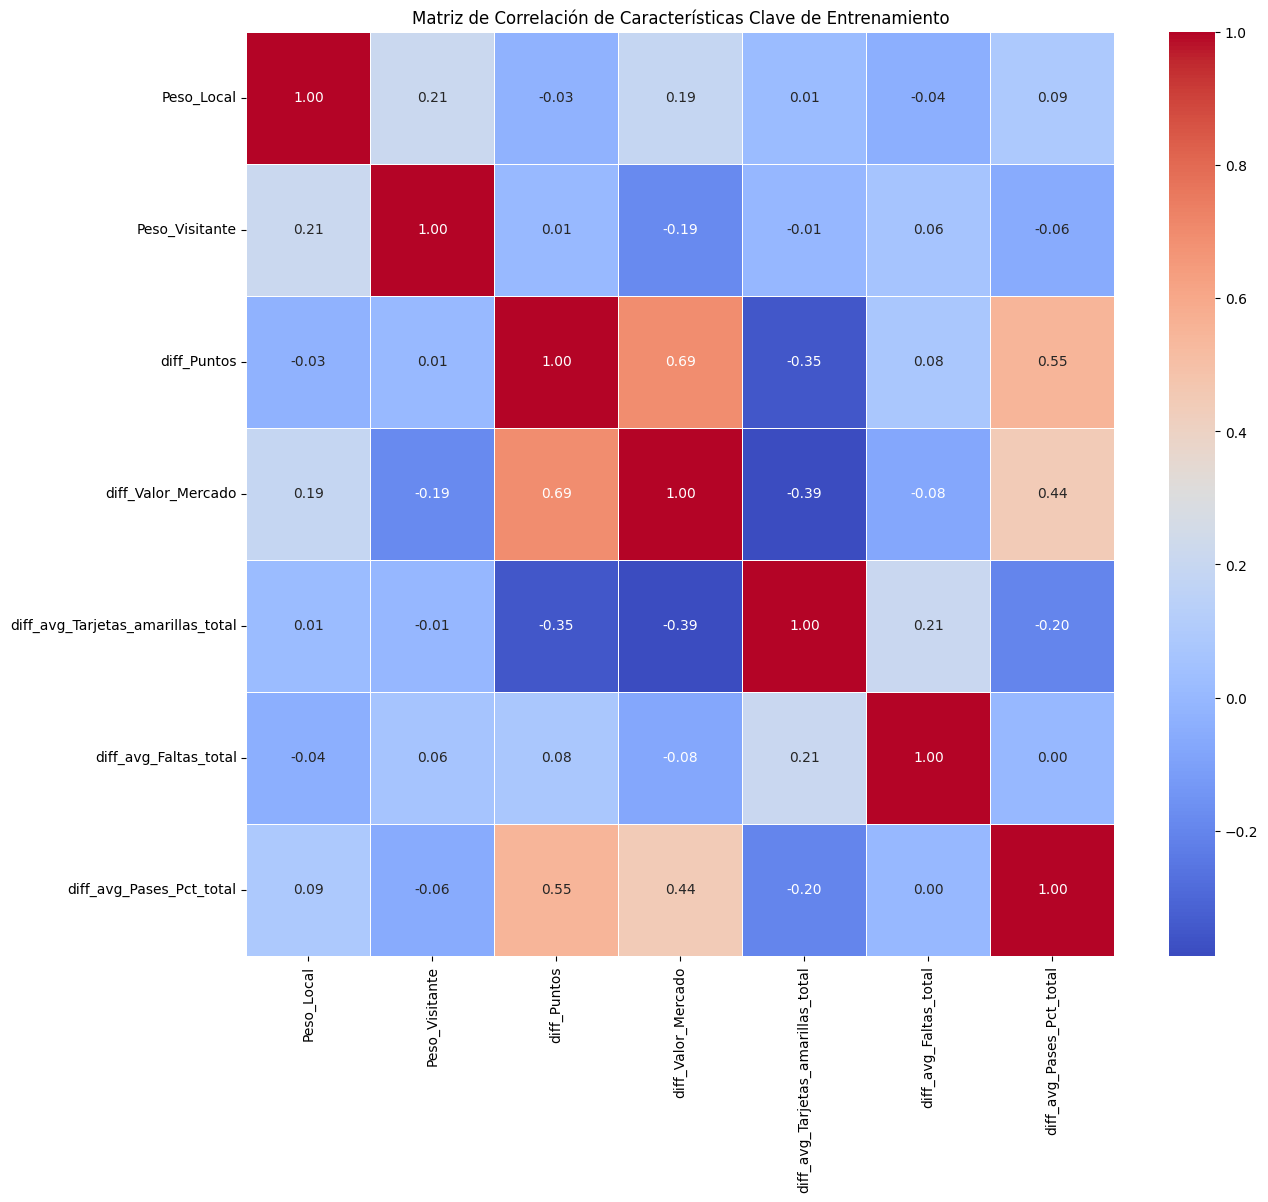


Análisis de las correlaciones con 'diff_Puntos':
diff_Puntos                          1.000000
diff_Valor_Mercado                   0.692345
diff_avg_Pases_Pct_total             0.545412
diff_avg_Faltas_total                0.075020
Peso_Visitante                       0.007799
Peso_Local                          -0.028354
diff_avg_Tarjetas_amarillas_total   -0.350433
Name: diff_Puntos, dtype: float64


In [ ]:
|import matplotlib.pyplot as plt
import seaborn as sns

# X_full ya está disponible en el scope global y contiene los datos
# correctos con 1396 filas tras la corrección en el Paso 5.

print(f"Dimensiones de X_full: {X_full.shape}")

# Seleccionar las columnas relevantes para el análisis de la fuerza
# Incluimos diff_Puntos y algunas otras diferencias clave
columnas_clave = [
    'diff_Puntos',
    'diff_Valor_Mercado',
    'diff_avg_Goles_esperados_(xG)_total',
    'diff_avg_Posesión_total',
    'diff_avg_Remates_a_puerta_total',
    'diff_avg_Córneres_total',
    'diff_avg_Tarjetas_amarillas_total',
    'diff_avg_Faltas_total',
    'diff_avg_Pases_Pct_total'
]

# Filtrar las columnas que realmente existen en X_full
columnas_clave_existentes = [col for col in columnas_clave if col in X_full.columns]

if not columnas_clave_existentes:
    print("Advertencia: Ninguna de las columnas clave de diferencia fue encontrada en X_full. Calculando la matriz de correlación completa.")
    corr_matrix = X_full.corr()
else:
    print(f"Calculando matriz de correlación para {len(columnas_clave_existentes)} columnas clave...")
    # Incluir las características originales de Peso_Local/Visitante si existen
    if 'Peso_Local' in X_full.columns: columnas_clave_existentes.insert(0, 'Peso_Local')
    if 'Peso_Visitante' in X_full.columns: columnas_clave_existentes.insert(1, 'Peso_Visitante')

    # Para evitar duplicados en la lista de columnas para la correlación
    columnas_final_corr = list(dict.fromkeys(columnas_clave_existentes))
    corr_matrix = X_full[columnas_final_corr].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Características Clave de Entrenamiento')
plt.show()

print("\nAnálisis de las correlaciones con 'diff_Puntos':")
if 'diff_Puntos' in corr_matrix.index:
    print(corr_matrix['diff_Puntos'].sort_values(ascending=False))


In [ ]:
# ====================================================================
# PASO 8: VISUALIZACIÓN DE RESULTADOS
# ====================================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("PASO 8: VISUALIZACIÓN DE RESULTADOS")
print("="*60)

# ----------------------------------------------------------------
# 8.1. Gráfico de barras - Top 20
# ----------------------------------------------------------------
top_20 = df_probs.head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_20, x='Prob_Clasificacion_%', y='Equipo', palette='viridis')
plt.xlabel('Probabilidad de Clasificación a Octavos (%)')
plt.title('Top 20 Equipos con Mayor Probabilidad de Clasificar a Octavos del Mundial 2026')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# 8.2. Probabilidades por grupo
# ----------------------------------------------------------------
print("\n📊 Probabilidades de clasificación por grupo:")
for grupo, equipos in grupos_dict.items():
    print(f"\n  Grupo {grupo}:")
    for equipo in sorted(equipos):
        prob = df_probs[df_probs['Equipo'] == equipo]['Prob_Clasificacion_%'].values
        prob_val = prob[0] if len(prob) > 0 else 0.0
        print(f"    {equipo}: {prob_val:.1f}%")